# Predicting Earthquake Magnitude: A Real Phantom Edge

The size of the next earthquake is, to first order, not predictable
from the sizes of the previous ones. Gutenberg-Richter says
magnitudes are roughly exponentially distributed and serially almost
independent. So the honest predictive R-squared here is about zero,
and we know that going in — which is exactly what makes this a clean
test on real data, not a toy.

Data: the USGS global earthquake catalog (`earthquake.usgs.gov`),
M5.0+ events 2014-2024. Public domain, no key, ~3 MB; downloaded
once and cached in `examples/data/` (git-ignored), offline after.

The label is the mean magnitude over the next 20 events, so adjacent
labels overlap heavily. One feature is the cumulative event count —
a real quantity seismologists track that also happens to be a
monotone clock. Both of those are realistic, and both are exactly
what a leaky split exploits. Numbers below are the real run.

In [1]:
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, cross_val_score
from sklearn.neighbors import KNeighborsRegressor

from purgedcv import PurgedKFold, WalkForwardSplit
from purgedcv.diagnostics import compute_overlap_fraction

SEED = 0
H = 20  # label = mean magnitude over the next H events
N_SPLITS = 5

## Download and cache the catalog

A fixed query window keeps the result reproducible; historical
events do not change.

In [2]:
DATA_DIR = Path("data") if Path("data").exists() else Path("examples/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
cache = DATA_DIR / "usgs_quakes_m5_2014_2024.csv"

if cache.exists():
    print(f"Using cached: {cache}")
    eq = pd.read_csv(cache)
else:
    url = (
        "https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv"
        "&starttime=2014-01-01&endtime=2024-01-01&minmagnitude=5.0"
        "&orderby=time-asc&limit=20000"
    )
    req = urllib.request.Request(url, headers={"User-Agent": "purgedcv-examples"})
    with urllib.request.urlopen(req, timeout=120) as r:
        eq = pd.read_csv(r, usecols=["time", "mag", "depth"])
    eq.to_csv(cache, index=False)
    print(f"Downloaded USGS catalog -> cached {cache}")

eq = eq.dropna(subset=["time", "mag"])
eq["time"] = pd.to_datetime(eq["time"], format="mixed", utc=True)
eq = eq.sort_values("time").reset_index(drop=True)
print(f"{len(eq)} events, M5.0+, {eq['time'].min().date()} to {eq['time'].max().date()}")

Downloaded USGS catalog -> cached data/usgs_quakes_m5_2014_2024.csv
17245 events, M5.0+, 2014-01-01 to 2023-12-31


## Features and the overlapping label

Sensible inputs: the last magnitude, a short rolling mean, depth,
and the cumulative event index. The target is the mean magnitude of
the next `H` events. None of these can really forecast the next
magnitudes; the point is what a leaky split does anyway.

In [3]:
mag = eq["mag"].to_numpy()
depth = eq["depth"].fillna(eq["depth"].median()).to_numpy()
n = len(eq) - H

lag1 = mag[:n]
roll10 = pd.Series(mag).rolling(10).mean().shift(1).to_numpy()[:n]
cum_idx = np.arange(n, dtype=float)  # cumulative event count (a real, monotone clock)
feat = np.column_stack([lag1, roll10, depth[:n], cum_idx])
y = np.array([mag[i + 1 : i + 1 + H].mean() for i in range(n)])

ok = np.isfinite(feat).all(axis=1)
X = feat[ok]
y = y[ok]
pred = eq["time"].dt.tz_localize(None).iloc[:n][ok].reset_index(drop=True)
evalu = pred + pd.Timedelta(days=60)

corr = np.corrcoef(X[:, 0], y)[0, 1]
print(f"usable events: {len(y)}")
print(
    f"corr(last magnitude, next-{H}-mean) = {corr:+.3f}  "
    "(near zero: magnitude is not predictable from magnitude)"
)

usable events: 17215
corr(last magnitude, next-20-mean) = +0.023  (near zero: magnitude is not predictable from magnitude)


## Naive shuffled k-fold vs honest splits

Shuffling scatters each event's neighbours into training; their
labels are nearly the same number, and the monotone event index
lets the model find them. `PurgedKFold` and `WalkForwardSplit`
remove that crutch.

In [4]:
model = KNeighborsRegressor(n_neighbors=10)
naive = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
blocked = KFold(n_splits=N_SPLITS, shuffle=False)
purged = PurgedKFold(
    n_splits=N_SPLITS,
    prediction_times=pred,
    evaluation_times=evalu,
    purge_horizon="60D",
    embargo="60D",
)
wf = WalkForwardSplit(
    n_splits=N_SPLITS,
    test_size=len(y) // 8,
    window="expanding",
    prediction_times=pred,
    evaluation_times=evalu,
    purge_horizon="60D",
)

scores = {"true (by construction)": 0.0}
for name, cv in [
    ("naive shuffled k-fold", naive),
    ("blocked k-fold", blocked),
    ("PurgedKFold", purged),
    ("WalkForwardSplit", wf),
]:
    scores[name] = round(float(cross_val_score(model, X, y, cv=cv, scoring="r2").mean()), 3)


def mean_overlap(cv):
    fr = [compute_overlap_fraction(tr, te, pred, evalu) for tr, te in cv.split(X)]
    return float(np.mean(fr))


pd.Series(scores, name="R^2").to_frame()

,R^2
true (by construction),0.000
naive shuffled k-fold,0.645
blocked k-fold,-1.132
PurgedKFold,-0.748
WalkForwardSplit,-1.240


In [5]:
print(f"label overlap, naive shuffled : {mean_overlap(naive):.0%}")
print(f"label overlap, PurgedKFold    : {mean_overlap(purged):.0%}")

label overlap, naive shuffled : 100%
label overlap, PurgedKFold    : 0%


## The phantom edge, in one chart

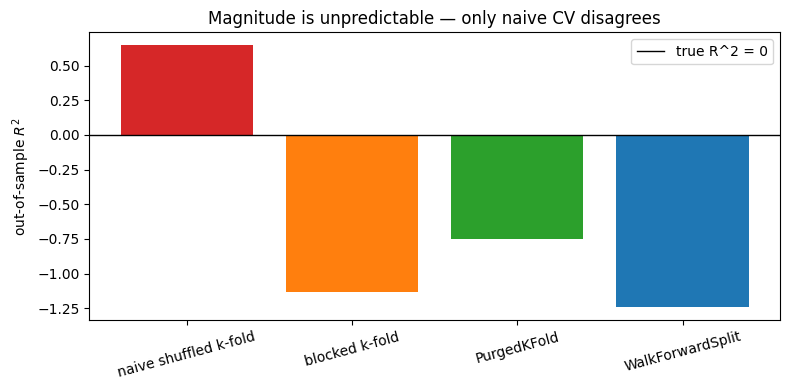

In [6]:
import matplotlib.pyplot as plt

names = [k for k in scores if k != "true (by construction)"]
vals = [scores[k] for k in names]
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]
ax.bar(names, vals, color=colors)
ax.axhline(0.0, color="black", linewidth=1, label="true R^2 = 0")
ax.set_ylabel("out-of-sample $R^2$")
ax.set_title("Magnitude is unpredictable — only naive CV disagrees")
ax.tick_params(axis="x", rotation=15)
ax.legend()
plt.tight_layout()
plt.show()

## Verdict

The size of the next earthquake cannot be read from the sizes of the last
ones. The correlation here is +0.02. Seismology says the same. So the
honest R-squared is zero, and we knew that before running anything.

Naive shuffled k-fold reports R-squared = 0.65. That is not skill — it is
pure leakage. Shuffling drops each event's neighbours into training,
their next-20-mean labels are almost the same number, and the cumulative
event index walks the model straight to them. Every honest split refuses
the shortcut: blocked, PurgedKFold and WalkForward all land firmly
negative — the correct answer for an unpredictable target. PurgedKFold
cuts the label overlap from 100% to 0%, and the phantom edge dies with
it.

This is the same trap as `synthetic_leakage_proof.ipynb` and
`ohlc_trading_signal.ipynb`, now on a real scientific catalog where the
unpredictability is established fact, not an assumption. The lesson is
blunt: if your cross-validation says you can forecast earthquake
magnitude, your cross-validation is broken, not your model.

**Data:** USGS global earthquake catalog
(`earthquake.usgs.gov`), M5.0+ events 2014-2023. U.S. Geological Survey,
public domain.